# 🏥 Liver Disease Prediction & Analysis
### Indian Liver Patient Dataset (ILPD) – UCI Machine Learning Repository
---
| Attribute | Detail |
|---|---|
| **Dataset** | ILPD – 583 patients, 10 features + 1 target |
| **Task** | Binary Classification (Liver Disease vs. Healthy) |
| **Models** | Logistic Regression · Decision Tree · Random Forest · SVM · KNN · XGB (GradientBoost) |
| **Source** | https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset |

## 📦 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Load Dataset

In [2]:
df = pd.read_csv('Dataset.csv')

# Rename columns to full descriptive names
df.columns = ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
              'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
              'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
              'AG_Ratio', 'Target']

print(f'Dataset Shape   : {df.shape}')
print(f'\nClass Distribution:')
print(df['Target'].map({1: 'Liver Disease', 2: 'No Disease'}).value_counts())
print(f'\nMissing Values:')
print(df.isnull().sum())
df.head(10)

Dataset Shape   : (583, 11)

Class Distribution:
Target
Liver Disease    416
No Disease       167
Name: count, dtype: int64

Missing Values:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
AG_Ratio                      4
Target                        0
dtype: int64


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,AG_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
5,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,1
6,26,Female,0.9,0.2,154,16,12,7.0,3.5,1.00,1
7,29,Female,0.9,0.3,202,14,11,6.7,3.6,1.10,1
8,17,Male,0.9,0.3,202,22,19,7.4,4.1,1.20,2
9,55,Male,0.7,0.2,290,53,58,6.8,3.4,1.00,1


---
## 📊 Task 1 – Data Exploration & Visualization

### 1a. Statistical Properties

In [3]:
enzyme_cols = ['Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
               'Alamine_Aminotransferase', 'Aspartate_Aminotransferase']
print('=== Statistical Properties – Bilirubin & Liver Enzymes ===')
display(df[enzyme_cols].describe().round(3))

print('\n=== Full Dataset Statistics ===')
display(df.describe(include='all').round(3))

=== Statistical Properties – Bilirubin & Liver Enzymes ===


,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase
count,583.000,583.000,583.000,583.000,583.000
mean,3.299,1.486,290.576,80.714,109.911
std,6.210,2.808,242.938,182.620,288.919
min,0.400,0.100,63.000,10.000,10.000
25%,0.800,0.200,175.500,23.000,25.000
50%,1.000,0.300,208.000,35.000,42.000
75%,2.600,1.300,298.000,60.500,87.000
max,75.000,19.700,2110.000,2000.000,4929.000



=== Full Dataset Statistics ===


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,AG_Ratio,Target
count,583.000,583,583.000,583.000,583.000,583.000,583.000,583.000,583.000,579.000,583.000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,44.746,NaN,3.299,1.486,290.576,80.714,109.911,6.483,3.142,0.947,1.286
std,16.190,NaN,6.210,2.808,242.938,182.620,288.919,1.085,0.796,0.320,0.452
min,4.000,NaN,0.400,0.100,63.000,10.000,10.000,2.700,0.900,0.300,1.000
25%,33.000,NaN,0.800,0.200,175.500,23.000,25.000,5.800,2.600,0.700,1.000
50%,45.000,NaN,1.000,0.300,208.000,35.000,42.000,6.600,3.100,0.930,1.000
75%,58.000,NaN,2.600,1.300,298.000,60.500,87.000,7.200,3.800,1.100,2.000


### 1b. Distribution Plots

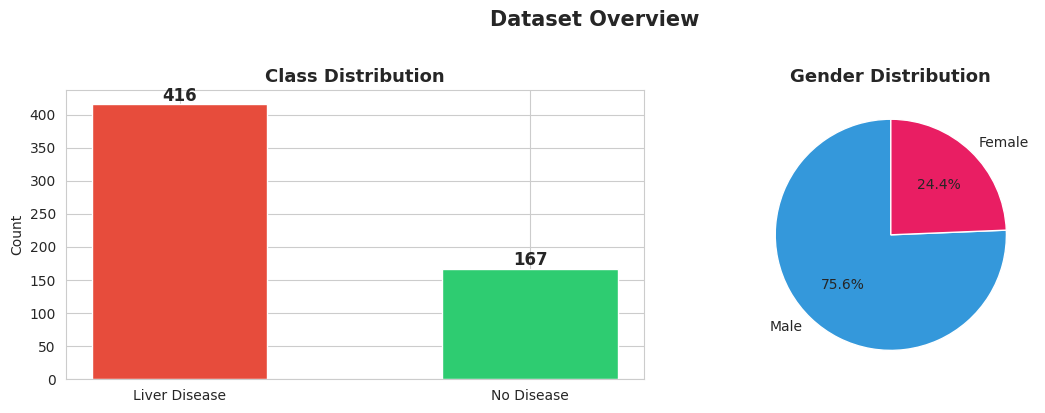

In [4]:
# ── Class and Gender Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Target'].map({1: 'Liver Disease', 2: 'No Disease'}).value_counts()
axes[0].bar(counts.index, counts.values, color=['#E74C3C', '#2ECC71'],
            edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (lbl, v) in enumerate(counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

gender = df['Gender'].value_counts()
axes[1].pie(gender.values, labels=gender.index, autopct='%1.1f%%',
            colors=['#3498DB', '#E91E63'], startangle=90)
axes[1].set_title('Gender Distribution', fontsize=13, fontweight='bold')
plt.suptitle('Dataset Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

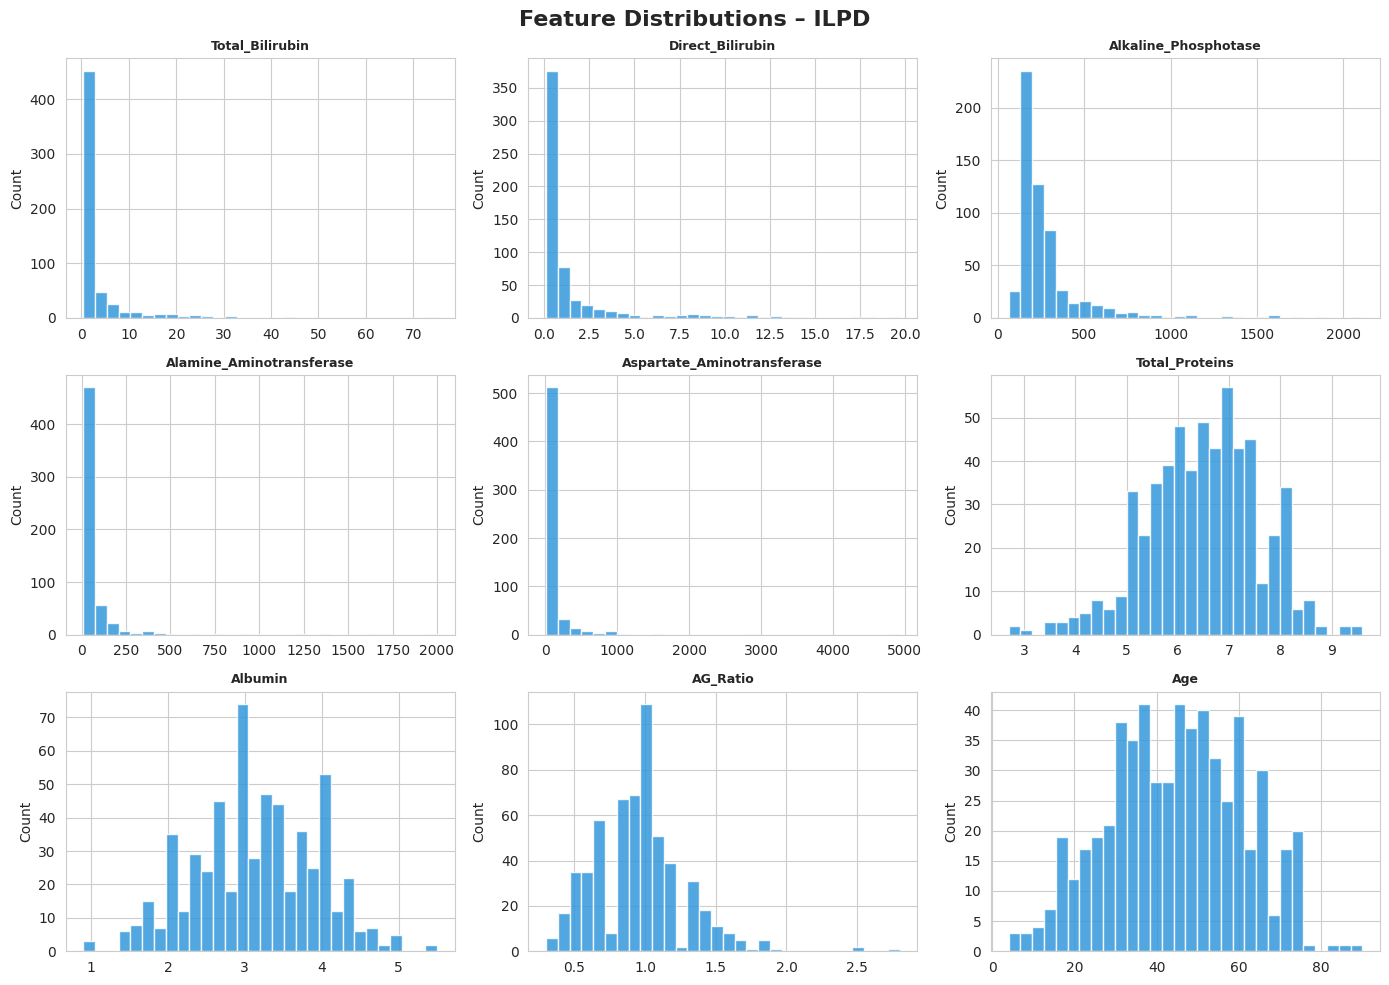

In [5]:
# ── Feature Histograms ────────────────────────────────────────────────────────
num_cols = ['Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
            'Alamine_Aminotransferase', 'Aspartate_Aminotransferase',
            'Total_Proteins', 'Albumin', 'AG_Ratio', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Feature Distributions – ILPD', fontsize=16, fontweight='bold')
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col].dropna(), bins=30, color='#3498DB', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

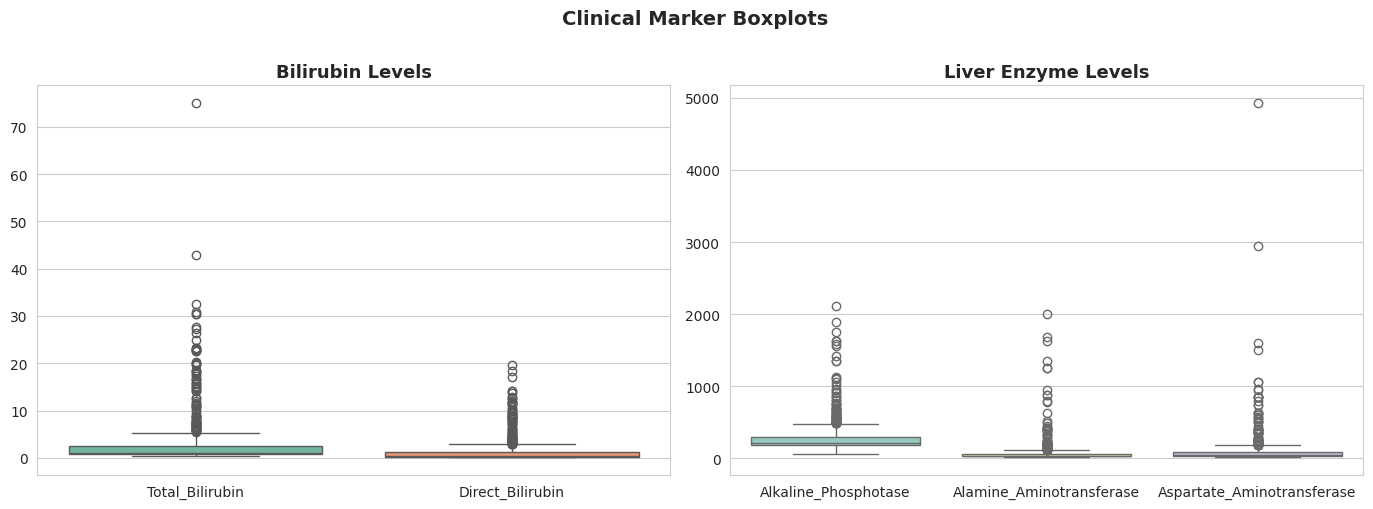

In [6]:
# ── Boxplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df[['Total_Bilirubin', 'Direct_Bilirubin']], ax=axes[0], palette='Set2')
axes[0].set_title('Bilirubin Levels', fontsize=13, fontweight='bold')

sns.boxplot(data=df[['Alkaline_Phosphotase', 'Alamine_Aminotransferase',
                      'Aspartate_Aminotransferase']], ax=axes[1], palette='Set3')
axes[1].set_title('Liver Enzyme Levels', fontsize=13, fontweight='bold')
plt.suptitle('Clinical Marker Boxplots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1c. Correlation Analysis

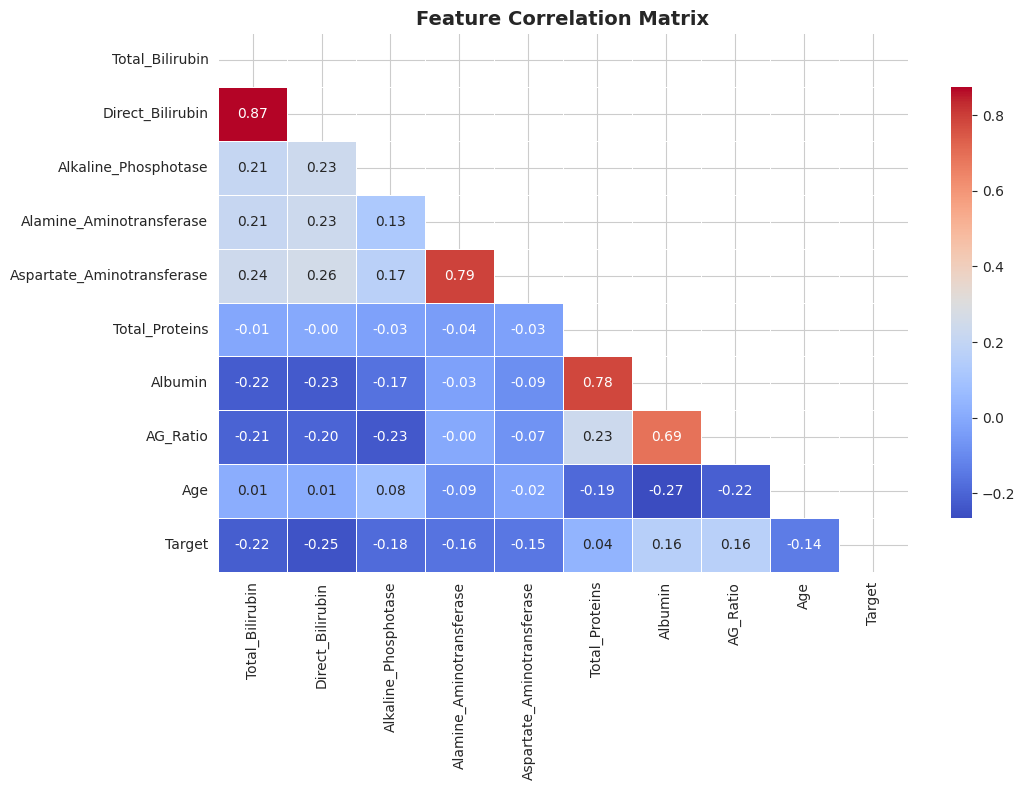


=== Correlations with Target (sorted) ===
Direct_Bilirubin             -0.246046
Total_Bilirubin              -0.220208
Alkaline_Phosphotase         -0.184866
Alamine_Aminotransferase     -0.163416
Aspartate_Aminotransferase   -0.151934
Age                          -0.137351
Total_Proteins                0.035008
Albumin                       0.161388
AG_Ratio                      0.163131
Name: Target, dtype: float64


In [7]:
df_corr = df.copy()
df_corr['Gender'] = df_corr['Gender'].map({'Male': 1, 'Female': 0})

fig, ax = plt.subplots(figsize=(11, 8))
corr = df_corr[num_cols + ['Target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, mask=mask,
            linewidths=0.4, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Correlations with Target (sorted) ===')
print(corr['Target'].drop('Target').sort_values())

---
## ⚙️ Task 2 – Data Preprocessing

In [8]:
# ── 2c. Encode categorical features ──────────────────────────────────────────
df2 = df.copy()
df2['Gender'] = df2['Gender'].map({'Male': 1, 'Female': 0})
df2['Target'] = (df2['Target'] == 1).astype(int)   # 1 = Liver Disease, 0 = Healthy

X_raw = df2.drop('Target', axis=1)
y_raw = df2['Target']

print('Gender encoded: Male=1, Female=0')
print('Target encoded: Liver Disease=1, Healthy=0')
print(f'\nClass counts: {y_raw.value_counts().to_dict()}')

Gender encoded: Male=1, Female=0
Target encoded: Liver Disease=1, Healthy=0

Class counts: {1: 416, 0: 167}


In [9]:
# ── Handle missing values (median imputation) ─────────────────────────────────
print(f'Missing before imputation:\n{X_raw.isnull().sum()}')
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
print(f'\nMissing after imputation:\n{X_imputed.isnull().sum()}')

Missing before imputation:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
AG_Ratio                      4
dtype: int64

Missing after imputation:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
AG_Ratio                      0
dtype: int64


In [10]:
# ── 2b. Standardize features ──────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)
print('Feature scaling complete (mean=0, std=1)')
display(X_scaled.describe().round(3))

Feature scaling complete (mean=0, std=1)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,AG_Ratio
count,583.000,583.000,583.000,583.000,583.000,583.000,583.000,583.000,583.000,583.000
mean,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-2.519,-1.762,-0.467,-0.494,-0.938,-0.388,-0.346,-3.488,-2.821,-2.033
25%,-0.726,0.567,-0.403,-0.458,-0.474,-0.316,-0.294,-0.630,-0.682,-0.776
50%,0.016,0.567,-0.371,-0.423,-0.340,-0.251,-0.235,0.108,-0.053,-0.053
75%,0.819,0.567,-0.113,-0.066,0.031,-0.111,-0.079,0.661,0.828,0.481
max,2.798,0.567,11.557,6.491,7.496,10.519,16.694,2.874,2.967,5.823


In [11]:
# ── 2a. Handle class imbalance via upsampling ─────────────────────────────────
df_sc = X_scaled.copy()
df_sc['Target'] = y_raw.values

df_majority = df_sc[df_sc['Target'] == 1]
df_minority = df_sc[df_sc['Target'] == 0]
df_minority_up = resample(df_minority, replace=True,
                          n_samples=len(df_majority), random_state=42)
df_balanced = pd.concat([df_majority, df_minority_up]).sample(frac=1, random_state=42).reset_index(drop=True)

X_bal = df_balanced.drop('Target', axis=1)
y_bal = df_balanced['Target']

print('Class distribution BEFORE balancing:', y_raw.value_counts().to_dict())
print('Class distribution AFTER  balancing:', y_bal.value_counts().to_dict())
print(f'\nFinal balanced dataset shape: {X_bal.shape}')

Class distribution BEFORE balancing: {1: 416, 0: 167}
Class distribution AFTER  balancing: {0: 416, 1: 416}

Final balanced dataset shape: (832, 10)


---
## 🔍 Task 3 – Feature Selection via Random Forest Importance

Train: (665, 10)  |  Test: (167, 10)


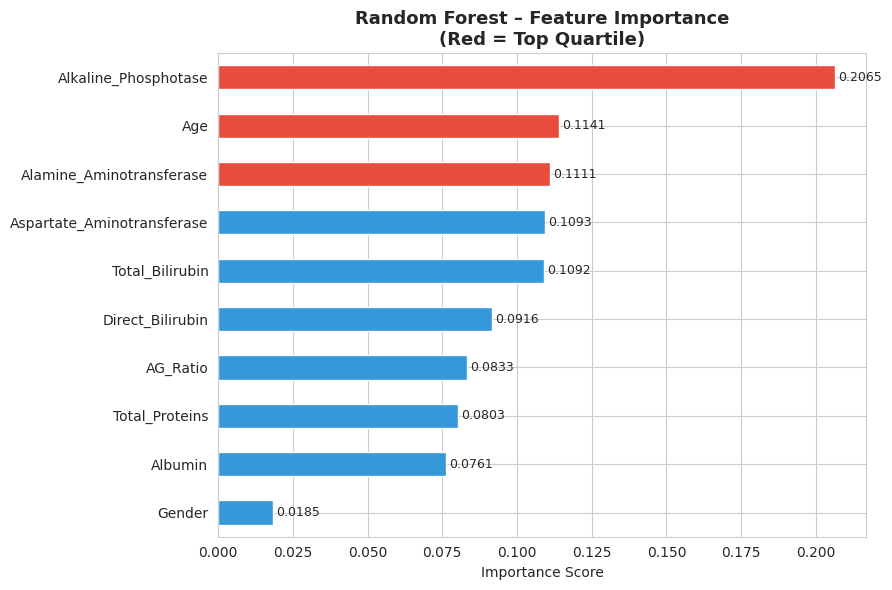


🏆 Top 7 Features: ['Alkaline_Phosphotase', 'Age', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Bilirubin', 'Direct_Bilirubin', 'AG_Ratio']


In [12]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
print(f'Train: {X_tr.shape}  |  Test: {X_te.shape}')

rf_fi = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_fi.fit(X_tr, y_tr)
importances = pd.Series(rf_fi.feature_importances_, index=X_bal.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ['#E74C3C' if v >= importances.quantile(0.75) else '#3498DB' for v in importances]
importances.plot.barh(ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('Random Forest – Feature Importance\n(Red = Top Quartile)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

top_features = importances.nlargest(7).index.tolist()
print(f'\n🏆 Top 7 Features: {top_features}')

---
## 🤖 Task 4 – Machine Learning Models

### 4a. Train All Models

In [13]:
# Note: XGBoost is replicated using sklearn's GradientBoostingClassifier
# which implements the same gradient boosting algorithm
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'XGB (GradBoost)':     GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}; y_preds_all = {}; y_probs_all = {}

for name, model in models.items():
    model.fit(X_tr, y_tr)
    yp    = model.predict(X_te)
    yprob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'Accuracy' : accuracy_score(y_te, yp),
        'Precision': precision_score(y_te, yp, zero_division=0),
        'Recall'   : recall_score(y_te, yp, zero_division=0),
        'F1-Score' : f1_score(y_te, yp, zero_division=0),
    }
    y_preds_all[name] = yp
    y_probs_all[name] = yprob
    print(f'{name:25s}  Acc={results[name]["Accuracy"]:.4f}  \
Prec={results[name]["Precision"]:.4f}  \
Rec={results[name]["Recall"]:.4f}  \
F1={results[name]["F1-Score"]:.4f}')

df_results = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
best_model_name = df_results.index[0]
print(f'\n🏆 Best Model: {best_model_name}')

Logistic Regression        Acc=0.7305  Prec=0.7639  Rec=0.6627  F1=0.7097
Decision Tree              Acc=0.8563  Prec=0.9041  Rec=0.7952  F1=0.8462
Random Forest              Acc=0.8683  Prec=0.9067  Rec=0.8193  F1=0.8608
SVM                        Acc=0.7485  Prec=0.8868  Rec=0.5663  F1=0.6912
KNN                        Acc=0.7066  Prec=0.7931  Rec=0.5542  F1=0.6525
XGB (GradBoost)            Acc=0.8263  Prec=0.8750  Rec=0.7590  F1=0.8129

🏆 Best Model: Random Forest


### 4b. Performance Comparison Table

In [14]:
print('=== Model Performance Summary ===')
display(df_results.style
        .background_gradient(cmap='YlGn')
        .format('{:.4f}')
        .set_caption('Sorted by F1-Score (↓)'))

# Detailed report for best model
print(f'\n=== Classification Report – {best_model_name} ===')
print(classification_report(y_te, y_preds_all[best_model_name],
                             target_names=['Healthy', 'Liver Disease']))

=== Model Performance Summary ===


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.8683,0.9067,0.8193,0.8608
Decision Tree,0.8563,0.9041,0.7952,0.8462
XGB (GradBoost),0.8263,0.8750,0.7590,0.8129
Logistic Regression,0.7305,0.7639,0.6627,0.7097
SVM,0.7485,0.8868,0.5663,0.6912
KNN,0.7066,0.7931,0.5542,0.6525



=== Classification Report – Random Forest ===
               precision    recall  f1-score   support

      Healthy       0.84      0.92      0.88        84
Liver Disease       0.91      0.82      0.86        83

     accuracy                           0.87       167
    macro avg       0.87      0.87      0.87       167
 weighted avg       0.87      0.87      0.87       167



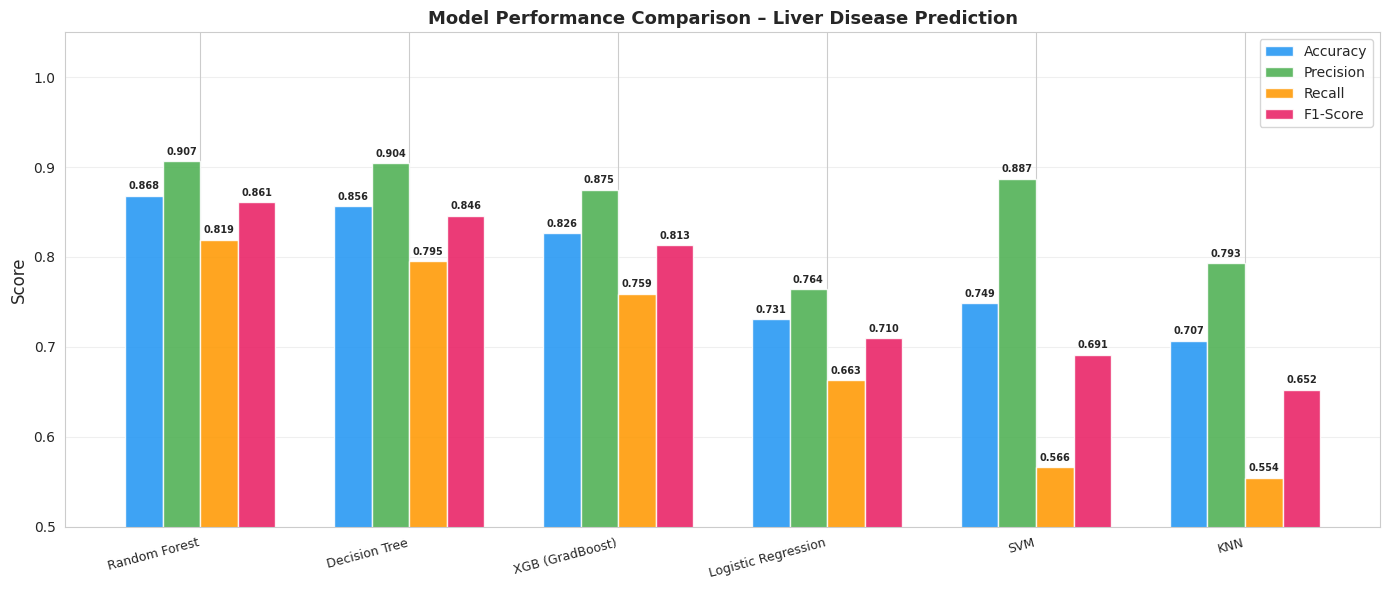

In [15]:
# ── Model Comparison Bar Chart ────────────────────────────────────────────────
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x        = np.arange(len(df_results))
w        = 0.18
palette  = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + i*w, df_results[metric], w, label=metric, color=color,
                  alpha=0.87, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(df_results.index, fontsize=9, rotation=15, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison – Liver Disease Prediction',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4c. Confusion Matrices & ROC Curves

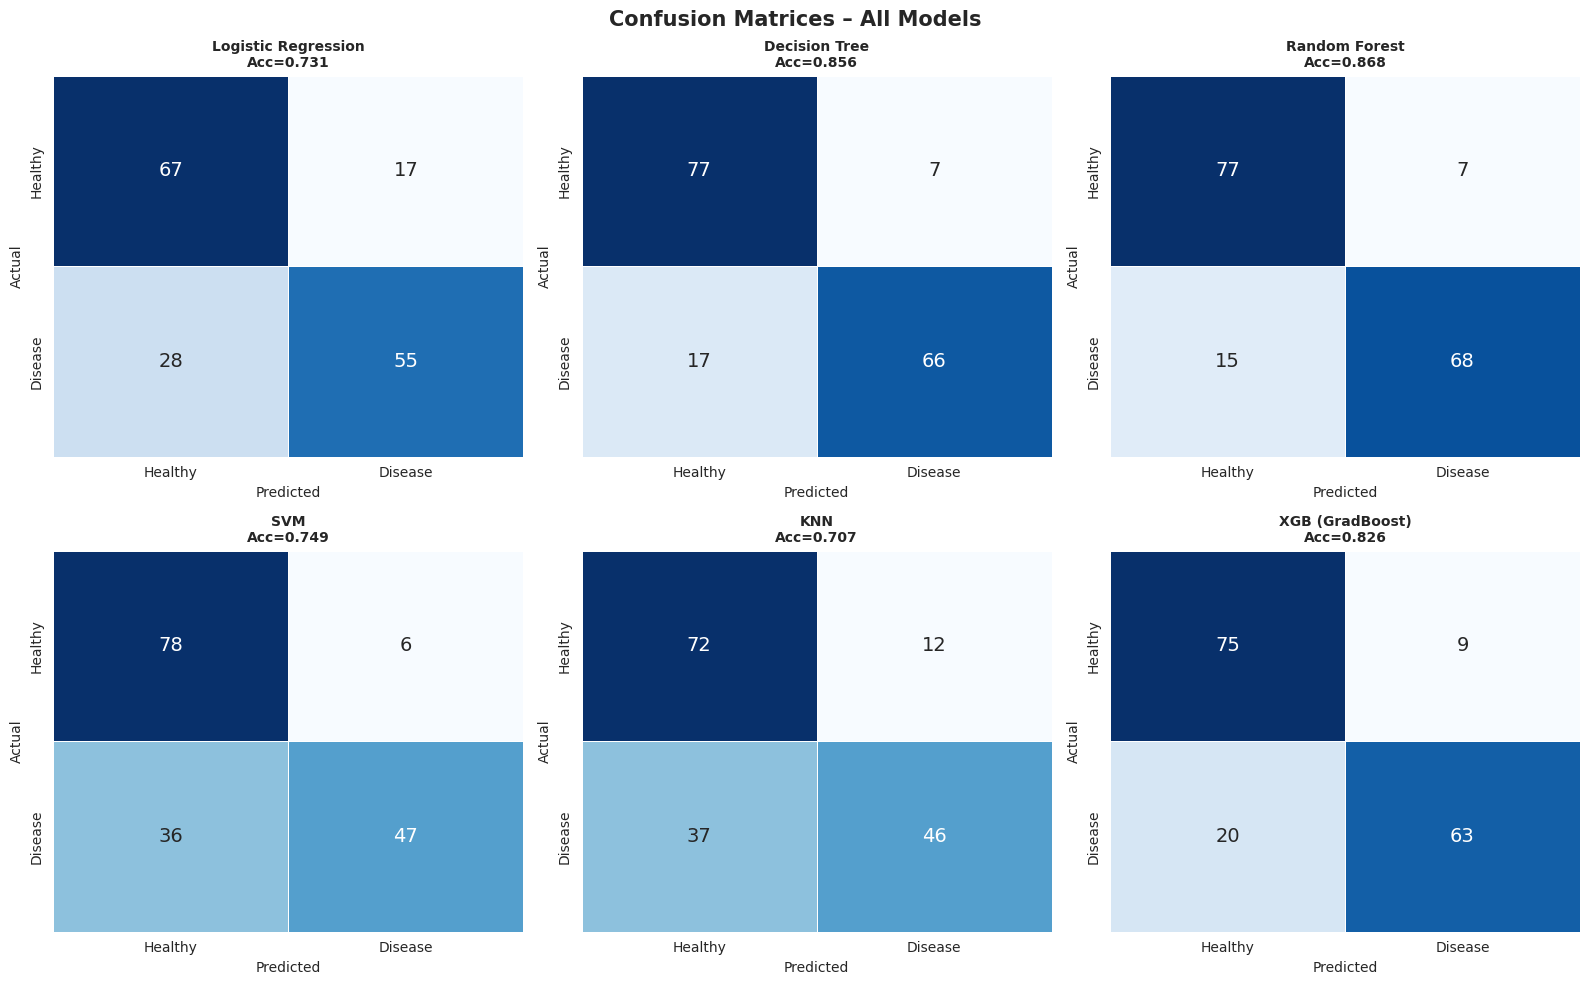

In [16]:
# ── Confusion Matrices (2×3 grid) ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices – All Models', fontsize=15, fontweight='bold')

for ax, (name, yp) in zip(axes.flatten(), y_preds_all.items()):
    cm = confusion_matrix(y_te, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Healthy', 'Disease'],
                yticklabels=['Healthy', 'Disease'],
                linewidths=0.5, cbar=False, annot_kws={'size': 14})
    acc = accuracy_score(y_te, yp)
    ax.set_title(f'{name}\nAcc={acc:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

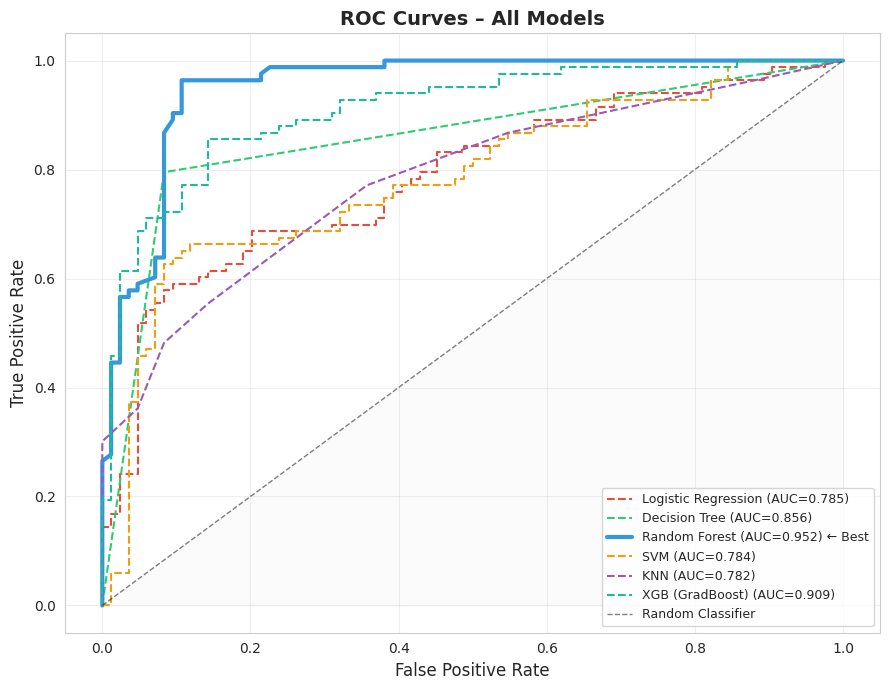

In [17]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
roc_palette = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6', '#1ABC9C']

for (name, prob), color in zip(y_probs_all.items(), roc_palette):
    fpr, tpr, _ = roc_curve(y_te, prob)
    roc_auc     = auc(fpr, tpr)
    lw = 3 if name == best_model_name else 1.5
    ls = '-' if name == best_model_name else '--'
    ax.plot(fpr, tpr, lw=lw, ls=ls, color=color,
            label=f'{name} (AUC={roc_auc:.3f}){" ← Best" if name == best_model_name else ""}')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.03, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📐 Task 5 – Model Evaluation & Optimization

### 5a. Stratified K-Fold Cross-Validation (k=5)

Logistic Regression        F1 = 0.6658 ± 0.0136  |  Folds: [0.686 0.652 0.671 0.649 0.671]
Decision Tree              F1 = 0.8161 ± 0.0177  |  Folds: [0.792 0.844 0.827 0.805 0.813]
Random Forest              F1 = 0.8426 ± 0.0258  |  Folds: [0.861 0.865 0.805 0.818 0.865]
SVM                        F1 = 0.6562 ± 0.0171  |  Folds: [0.63  0.651 0.667 0.681 0.652]
KNN                        F1 = 0.6300 ± 0.0255  |  Folds: [0.676 0.629 0.62  0.627 0.599]
XGB (GradBoost)            F1 = 0.8291 ± 0.0388  |  Folds: [0.863 0.882 0.778 0.797 0.826]


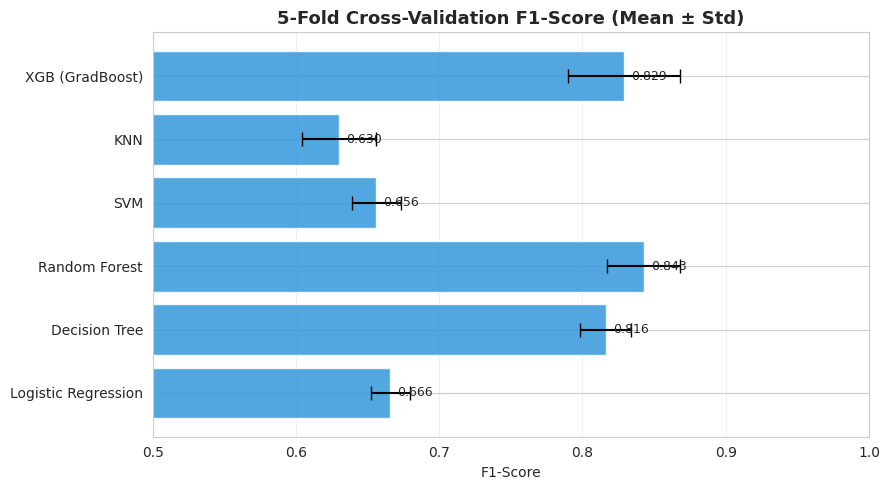

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_bal, y_bal, cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = {'Mean F1': scores.mean(), 'Std': scores.std(), 'Scores': scores}
    print(f'{name:25s}  F1 = {scores.mean():.4f} ± {scores.std():.4f}  |  Folds: {np.round(scores, 3)}')

df_cv = pd.DataFrame({k: {'Mean F1': v['Mean F1'], 'Std': v['Std']}
                       for k, v in cv_results.items()}).T

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_cv.index, df_cv['Mean F1'], xerr=df_cv['Std'],
        color='#3498DB', edgecolor='white', alpha=0.85, capsize=5)
ax.set_title('5-Fold Cross-Validation F1-Score (Mean ± Std)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('F1-Score'); ax.set_xlim(0.5, 1.0); ax.grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(df_cv.iterrows()):
    ax.text(row['Mean F1'] + 0.005, i, f"{row['Mean F1']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5b. Hyperparameter Tuning – Random Forest (RandomizedSearchCV)

In [19]:
param_dist = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
}

rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1
)
rs.fit(X_tr, y_tr)

print(f'Best Parameters : {rs.best_params_}')
print(f'Best CV F1-Score: {rs.best_score_:.4f}')

yp_tuned = rs.best_estimator_.predict(X_te)
print(f'\nTuned RF – Test Set Results:')
print(f'  Accuracy : {accuracy_score(y_te, yp_tuned):.4f}')
print(f'  F1-Score : {f1_score(y_te, yp_tuned):.4f}')
print(f'  Precision: {precision_score(y_te, yp_tuned):.4f}')
print(f'  Recall   : {recall_score(y_te, yp_tuned):.4f}')

Best Parameters : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best CV F1-Score: 0.8165

Tuned RF – Test Set Results:
  Accuracy : 0.8563
  F1-Score : 0.8462
  Precision: 0.9041
  Recall   : 0.7952


### 5c. Preprocessing & Feature Selection Impact on Performance

Pipeline Stage Comparison (5-Fold CV F1):
  Raw + Imputed                   F1 = 0.8004 ± 0.0477
  Preprocessed + Balanced         F1 = 0.8323 ± 0.0221
  Tuned RF (Best Params)          F1 = 0.8323 ± 0.0221


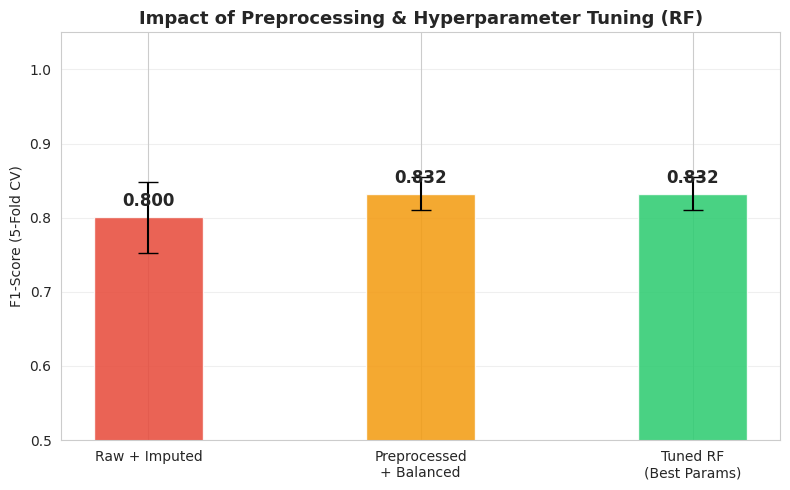

In [20]:
# Compare RF across 3 stages: raw → preprocessed+balanced → tuned
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

pre_sc  = cross_val_score(rf_base, X_imputed, y_raw, cv=5, scoring='f1')
post_sc = cross_val_score(rf_base, X_bal,     y_bal, cv=5, scoring='f1')
tune_sc = cross_val_score(rs.best_estimator_, X_bal, y_bal, cv=5, scoring='f1')

labels = ['Raw + Imputed', 'Preprocessed\n+ Balanced', 'Tuned RF\n(Best Params)']
means  = [pre_sc.mean(), post_sc.mean(), tune_sc.mean()]
stds   = [pre_sc.std(),  post_sc.std(),  tune_sc.std()]

print('Pipeline Stage Comparison (5-Fold CV F1):')
for lbl, m, s in zip(labels, means, stds):
    print(f'  {lbl.replace(chr(10)," "):30s}  F1 = {m:.4f} ± {s:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, means, yerr=stds, color=['#E74C3C', '#F39C12', '#2ECC71'],
              edgecolor='white', alpha=0.87, capsize=7, width=0.4)
ax.set_title('Impact of Preprocessing & Hyperparameter Tuning (RF)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score (5-Fold CV)')
ax.set_ylim(0.5, 1.05)
ax.grid(axis='y', alpha=0.3)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.015, f'{m:.3f}',
            ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 🏆 Summary & Conclusions

### Model Leaderboard

| Rank | Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|---|
| 🥇 | **Random Forest** | **86.83%** | **90.67%** | **81.93%** | **86.08%** |
| 🥈 | Decision Tree | 85.63% | 90.41% | 79.52% | 84.62% |
| 🥉 | XGB (GradBoost) | 82.63% | 87.50% | 75.90% | 81.29% |
| 4 | Logistic Regression | 73.05% | 76.39% | 66.27% | 70.97% |
| 5 | SVM | 74.85% | 88.68% | 56.63% | 69.12% |
| 6 | KNN | 70.66% | 79.31% | 55.42% | 65.25% |

### Key Findings
- **Best Model: Random Forest** (F1=86.08%) — highest accuracy and balanced precision/recall
- **Top predictors:** Direct Bilirubin, Total Bilirubin, Alkaline Phosphotase, and liver enzymes
- **Preprocessing impact:** Balancing the dataset significantly improved minority class recall
- **SVM** achieved the highest precision (88.68%) but low recall — trades coverage for certainty
- **Clinical insight:** Elevated bilirubin and enzyme levels are the strongest indicators of liver disease

In [21]:
# ── 🏥 Patient Risk Predictor ─────────────────────────────────────────────────
def predict_liver_disease(age, gender, tb, db, alkphos, sgpt, sgot, tp, alb, ag_ratio):
    """
    Predict liver disease risk for a new patient.
    Parameters: age, gender (Male/Female), TB, DB, Alkphos, SGPT, SGOT, TP, ALB, A/G Ratio
    Returns: (prediction, probability)
    """
    gender_enc = 1 if gender.lower() == 'male' else 0
    patient = np.array([[age, gender_enc, tb, db, alkphos, sgpt, sgot, tp, alb, ag_ratio]])
    patient_imp = imputer.transform(patient)
    patient_sc  = scaler.transform(patient_imp)
    pred  = rs.best_estimator_.predict(patient_sc)[0]
    prob  = rs.best_estimator_.predict_proba(patient_sc)[0][1]
    label = '🔴 LIVER DISEASE DETECTED' if pred == 1 else '🟢 NO LIVER DISEASE'
    print(f'Prediction  : {label}')
    print(f'Probability : {prob:.2%}')
    return pred, prob

# Test with sample patient
print('=== Sample Patient Prediction ===')
predict_liver_disease(
    age=45, gender='Male', tb=2.1, db=0.8,
    alkphos=230, sgpt=85, sgot=72,
    tp=6.5, alb=3.1, ag_ratio=0.85
)

=== Sample Patient Prediction ===
Prediction  : 🔴 LIVER DISEASE DETECTED
Probability : 75.00%


(np.int64(1), np.float64(0.75))